# Natural Language Processing with Disaster Tweets

**Task**  
Predict which Tweets are about real disasters and which ones are not.

**Columns:**
- ID
- Keyword
- Location
- Text
- Target (Only train.csv have)

**Link to dataset:**  
https://www.kaggle.com/competitions/nlp-getting-started/data

**Code is referenced from @Humayun Kayesh**  

### Import Package

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.callbacks import ModelCheckpoint
from transformers import AutoTokenizer
from transformers import create_optimizer
from transformers import DataCollatorWithPadding
from transformers import TFAutoModelForSequenceClassification

os.environ["TOKENIZERS_PARALLELISM"] = "false" # Stop Warnings

2022-06-01 15:18:23.783879: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-06-01 15:18:23.783897: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.9) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/home/feng/.local/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read and Split Dataset

In [2]:
training_file = "dataset/train.csv"
test_file = "dataset/test.csv"
output_dir1 = './model2_outputs'
output_dir2 = './model3_outputs'
batch_size = 16

In [3]:
df = load_dataset('csv', data_files = [training_file])
df = df['train'].train_test_split(test_size = 0.1)
df['valid'] = df['test']
df['test'] = load_dataset('csv', data_files = [test_file])['train']

Using custom data configuration default-dacd6034bd90bc38
Reusing dataset csv (/home/feng/.cache/huggingface/datasets/csv/default-dacd6034bd90bc38/0.0.0/433e0ccc46f9880962cc2b12065189766fbb2bee57a221866138fb9203c83519)
100%|██████████| 1/1 [00:00<00:00, 1051.47it/s]
Using custom data configuration default-60f927a822212e41
Reusing dataset csv (/home/feng/.cache/huggingface/datasets/csv/default-60f927a822212e41/0.0.0/433e0ccc46f9880962cc2b12065189766fbb2bee57a221866138fb9203c83519)
100%|██████████| 1/1 [00:00<00:00, 259.50it/s]


#### Now we can observe the dataset

In [4]:
pd.DataFrame(df['train'])

,id,keyword,location,text,target
0,7352,obliterate,Seattle,#fun #instagramers http://t.co/M3NJvvtYgN\n\nJ...,0
1,4752,evacuate,None,quick shut down the show take the stage down e...,0
2,697,attacked,"Port Jervis, NY",My dog attacked me for my food #pugprobs,0
3,8760,siren,Michel Delving.,Apparently they're going to have a WW2 siren t...,0
4,398,apocalypse,None,will there be another jocelyn birthday apocalypse,0
...,...,...,...,...,...
6846,8905,snowstorm,"Hampshire, UK",New #photo Oak in a snowstorm http://t.co/HK9Y...,1
6847,9830,trauma,www.aprylpooley.com,A1: I started writing when I couldn't talk abo...,0
6848,8558,screams,Freddy Fazbears pizzeria,@drag0nking0201 *Screams*don't scare me and it...,0
6849,4365,earthquake,"California, USA",#USGS M 1.2 - 23km S of Twentynine Palms Calif...,1


In [5]:
pd.DataFrame(df['train']).isna().sum() # Count the missing value

id             0
keyword       60
location    2285
text           0
target         0
dtype: int64

In [6]:
pd.DataFrame(df['valid'])

,id,keyword,location,text,target
0,2038,casualties,50% Queanbeyan - 50% Sydney,@FlyOpineMonkey You mean Olympic ;-) \nAlso it...,1
1,5224,fatality,Rafael castillo,fatality,0
2,10110,upheaval,Oregon,A look at state actions a year after Ferguson'...,0
3,1572,bomb,None,The bomb was so appropriate ?? seen as my fami...,0
4,5775,forest%20fires,None,U.S. Forest Service says spending more than ha...,1
...,...,...,...,...,...
757,2463,collided,None,I scored 111020 points in PUNCH QUEST stopped ...,1
758,4088,displaced,None,PennLive - Two families displaced by Mechanics...,1
759,4709,epicentre,None,Epicentre - Cydia Tweak - https://t.co/WKmfDig...,0
760,8939,snowstorm,"Austin, TX",@PrablematicLA @Adweek I'm actually currently ...,1


In [7]:
pd.DataFrame(df['valid']).isna().sum() # Count the missing value

id            0
keyword       1
location    248
text          0
target        0
dtype: int64

In [8]:
pd.DataFrame(df['test'])

,id,keyword,location,text
0,0,None,None,Just happened a terrible car crash
1,2,None,None,"Heard about #earthquake is different cities, s..."
2,3,None,None,"there is a forest fire at spot pond, geese are..."
3,9,None,None,Apocalypse lighting. #Spokane #wildfires
4,11,None,None,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,None,None,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,None,None,Storm in RI worse than last hurricane. My city...
3260,10868,None,None,Green Line derailment in Chicago http://t.co/U...
3261,10874,None,None,MEG issues Hazardous Weather Outlook (HWO) htt...


In [9]:
pd.DataFrame(df['test']).isna().sum() # Count the missing value

id             0
keyword       26
location    1105
text           0
dtype: int64

Text(0, 0.5, 'Counts')

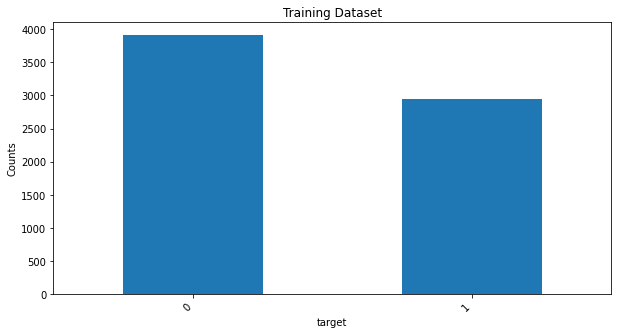

In [10]:
fig, axes = plt.subplots(figsize = (10, 5))

pd.DataFrame(df['train']).value_counts('target').reindex(index = [0, 1]).plot(kind = 'bar', ax = axes)
plt.sca(axes) # Set Axes
plt.xticks(rotation = 45, horizontalalignment = 'right')
plt.title('Training Dataset')
plt.ylabel('Counts')

## Naive Bayes (Baseline Model)

In [11]:
NB_model = make_pipeline(TfidfVectorizer(), MultinomialNB()) # Use TfidfVectorize() to convert word to vector, and MultinomialNB() to classify
NB_model.fit(df['train']['text'], df['train']['target'])

y_hat = NB_model.predict(df['valid']['text'])

In [12]:
print("Accuracy:", accuracy_score(df['valid']['target'], y_hat))

Accuracy: 0.8123359580052494


## DistilBERT

Padding adds a special padding token to ensure shorter sequences will have the same length as either the longest sequence in a batch or the maximum length accepted by the model.

Truncation works in the other direction by truncating long sequences.

### Tokenize the Inputs

In [13]:
distilBERTtokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased") # Get Predefined Distilbert Tokenizer

def distilBERTtokenize(row):
    return distilBERTtokenizer(row["text"], padding = "max_length", truncation = True) # Padding and Truncation to Max Model Input Length

origin_columns = set(df["train"].features) # Not yet tokenized dataset
encoded_df = df.map(distilBERTtokenize, batched = True) # Open Batch Processing, Default Batch Size is 1000
tokenizer_columns = list(set(encoded_df["train"].features) - origin_columns)
print("Columns added by tokenizer:", tokenizer_columns)

100%|██████████| 7/7 [00:00<00:00,  7.15ba/s]
Loading cached processed dataset at /home/feng/.cache/huggingface/datasets/csv/default-60f927a822212e41/0.0.0/433e0ccc46f9880962cc2b12065189766fbb2bee57a221866138fb9203c83519/cache-88e59bc8f88e4a02.arrow
100%|██████████| 1/1 [00:00<00:00,  9.53ba/s]

Columns added by tokenizer: ['attention_mask', 'input_ids']


Attention mask indicates to the model which tokens should be attended to, and which should not.

Input ids are token indices, numerical representations of tokens building the sequences that will be used as input by the model.

In [14]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'target'],
        num_rows: 6851
    })
    test: Dataset({
        features: ['id', 'keyword', 'location', 'text'],
        num_rows: 3263
    })
    valid: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'target'],
        num_rows: 762
    })
})

In [15]:
encoded_df

DatasetDict({
    train: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'target', 'input_ids', 'attention_mask'],
        num_rows: 6851
    })
    test: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'input_ids', 'attention_mask'],
        num_rows: 3263
    })
    valid: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'target', 'input_ids', 'attention_mask'],
        num_rows: 762
    })
})

In [16]:
data_collator = DataCollatorWithPadding(tokenizer = distilBERTtokenizer, return_tensors = "tf") # DataCollator that will dynamically pad the inputs received

train_df = encoded_df['train'].to_tf_dataset( # Create a tf.data.Dataset from the underlying Dataset, and is suitable for model.fit()
    columns = tokenizer_columns,
    label_cols = ["target"],
    shuffle = True,
    collate_fn = data_collator, # Set a function or callable object that will collate lists of samples into a batch
    batch_size = batch_size,
)

val_df = encoded_df['valid'].to_tf_dataset(
    columns = tokenizer_columns,
    label_cols = ["target"],
    shuffle = False,
    batch_size = batch_size,
    collate_fn = data_collator,
)

test_df = encoded_df['test'].to_tf_dataset(
    columns = tokenizer_columns,
    shuffle = False,
    batch_size = batch_size,
    collate_fn = data_collator,
)

2022-06-01 15:18:38.201429: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-06-01 15:18:38.201832: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-06-01 15:18:38.202215: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-06-01 15:18:38.202252: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2022-06-01 15:18:38.202286: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not lo

### Model Build

In [17]:
distilBERT_model = TFAutoModelForSequenceClassification.from_pretrained( # This is a generic model class can instantiate one of model of the library
    "distilbert-base-uncased", num_labels = 2                            # from_pretrained() can load model weights
)

distilBERT_model.summary()

2022-06-01 15:18:40.164957: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_projector', 'vocab_layer_norm', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint 

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMai  multiple                 66362880  
 nLayer)                                                         
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_19 (Dropout)        multiple                  0         
                                                                 
Total params: 66,955,010
Trainable params: 66,955,010
Non-trainable params: 0
_________________________________________________________________


In [18]:
num_epochs = 3
batches_per_epoch = len(encoded_df["train"]) // batch_size
total_train_steps = int(batches_per_epoch * num_epochs)

optimizer, schedule = create_optimizer(
    init_lr = 2e-5, num_warmup_steps = 0, num_train_steps = total_train_steps
)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
distilBERT_model.compile(optimizer = optimizer, loss = loss, metrics = ['accuracy'])

In [19]:
if not os.path.exists(output_dir1): # If the file directory doesn't already exists,
    os.makedirs(output_dir1) # Make it again

checkpoint_callback = ModelCheckpoint(filepath = output_dir1 + '/weights.{epoch:02d}.hdf5', monitor = 'val_loss', save_best_only = True, save_weights_only = True)

In [20]:
distilBERT_model.fit(
    train_df,
    validation_data = val_df,
    epochs = 3,
    callbacks = [checkpoint_callback],
)

Epoch 1/3
428/428 [==============================] - 2743s 6s/step - loss: 0.4341 - accuracy: 0.8124 - val_loss: 0.3658 - val_accuracy: 0.8465
Epoch 2/3
428/428 [==============================] - 2747s 6s/step - loss: 0.3154 - accuracy: 0.8791 - val_loss: 0.3610 - val_accuracy: 0.8530
Epoch 3/3
428/428 [==============================] - 2740s 6s/step - loss: 0.2429 - accuracy: 0.9115 - val_loss: 0.3900 - val_accuracy: 0.8491


### Predict and Output Test Dataset

In [21]:
test_pred = distilBERT_model.predict(test_df)

In [22]:
submission = pd.read_csv('dataset/sample_submission.csv')
submission['target'] = np.argmax(test_pred.logits, axis = 1)
submission.to_csv('submission.csv', index = False)

## BERT

### Tokenize the Inputs

In [23]:
BERTtokenizer = AutoTokenizer.from_pretrained("bert-base-uncased") # Get Predefined Distilbert Tokenizer

def BERTtokenize(row):
    return BERTtokenizer(row["text"], padding = "max_length", truncation = True) # Padding and Truncation to Max Model Input Length

origin_columns = set(df["train"].features) # Not yet tokenized dataset
encoded_df = df.map(BERTtokenize, batched = True) # Open Batch Processing, Default Batch Size is 1000
tokenizer_columns = list(set(encoded_df["train"].features) - origin_columns)
print("Columns added by tokenizer:", tokenizer_columns)

100%|██████████| 1/1 [00:00<00:00,  7.92ba/s]

Columns added by tokenizer: ['token_type_ids', 'attention_mask', 'input_ids']


In [24]:
data_collator = DataCollatorWithPadding(tokenizer = BERTtokenizer, return_tensors = "tf") # DataCollator that will dynamically pad the inputs received

train_df = encoded_df['train'].to_tf_dataset( # Create a tf.data.Dataset from the underlying Dataset, and is suitable for model.fit()
    columns = tokenizer_columns,
    label_cols = ["target"],
    shuffle = True,
    collate_fn = data_collator, # Set a function or callable object that will collate lists of samples into a batch
    batch_size = batch_size,
)

val_df = encoded_df['valid'].to_tf_dataset(
    columns = tokenizer_columns,
    label_cols = ["target"],
    shuffle = False,
    batch_size = batch_size,
    collate_fn = data_collator,
)

test_df = encoded_df['test'].to_tf_dataset(
    columns = tokenizer_columns,
    shuffle = False,
    batch_size = batch_size,
    collate_fn = data_collator,
)

### Model Build

In [25]:
BERT_model = TFAutoModelForSequenceClassification.from_pretrained( # This is a generic model class can instantiate one of model of the library
    "bert-base-uncased", num_labels = 2                            # from_pretrained() can load model weights
)

BERT_model.summary()

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_57 (Dropout)        multiple                  0         
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109,483,778
Trainable params: 109,483,778
Non-trainable params: 0
_________________________________________________________________


In [26]:
num_epochs = 3
batches_per_epoch = len(encoded_df["train"]) // batch_size
total_train_steps = int(batches_per_epoch * num_epochs)

optimizer, schedule = create_optimizer(
    init_lr = 2e-5, num_warmup_steps = 0, num_train_steps = total_train_steps
)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
BERT_model.compile(optimizer = optimizer, loss = loss, metrics = ['accuracy'])

In [27]:
if not os.path.exists(output_dir2): # If the file directory doesn't already exists,
    os.makedirs(output_dir2) # Make it again

checkpoint_callback = ModelCheckpoint(filepath = output_dir2 + '/weights.{epoch:02d}.hdf5', monitor = 'val_loss', save_best_only = True, save_weights_only = True)

In [28]:
BERT_model.fit(
    train_df,
    validation_data = val_df,
    epochs = 3,
    callbacks = [checkpoint_callback],
)

Epoch 1/3
428/428 [==============================] - 5759s 13s/step - loss: 0.4348 - accuracy: 0.8081 - val_loss: 0.3600 - val_accuracy: 0.8438
Epoch 2/3
428/428 [==============================] - 5749s 13s/step - loss: 0.3122 - accuracy: 0.8773 - val_loss: 0.3637 - val_accuracy: 0.8307
Epoch 3/3
428/428 [==============================] - 5908s 14s/step - loss: 0.2275 - accuracy: 0.9162 - val_loss: 0.4329 - val_accuracy: 0.8215


### Predict and Output Test Dataset

In [29]:
test_pred = BERT_model.predict(test_df)

In [30]:
submission = pd.read_csv('dataset/sample_submission.csv')
submission['target'] = np.argmax(test_pred.logits, axis = 1)
submission.to_csv('submission2.csv', index = False)